In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
import time

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATA_PATH = 'data/shakespeare.txt'
os.makedirs('data', exist_ok=True)

if not os.path.exists(DATA_PATH):
    import urllib.request
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    print("Downloading Tiny Shakespeare..")
    urllib.request.urlretrieve(url, DATA_PATH)
    print("Downloaded.")

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Corpus length:  {len(text):,} characters")
print(f"Sample:\n{text[:200]}")

chars    = sorted(set(text))             # set extracts every unique character no duplicates
VOCAB    = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}

print(f"\nVocab size: {VOCAB} unique characters")
print(f"Characters: {''.join(chars[:30])}...")

SEQ_LEN    = 100    # characters per training sequence
BATCH_SIZE = 128

# Encode entire corpus as integer indices
encoded = torch.tensor([char2idx[c] for c in text], dtype=torch.long)
print(f"\nEncoded shape: {encoded.shape}")

def make_batches(encoded, seq_len, batch_size):
    """
    Slice corpus into non-overlapping chunks,
    then stack into batches.
    Target = input shifted by 1 character.
    """
    # Trim to fit evenly
    n_seqs   = (len(encoded) - 1) // seq_len
    X_all    = torch.zeros(n_seqs, seq_len, dtype=torch.long)
    y_all    = torch.zeros(n_seqs, seq_len, dtype=torch.long)

    for i in range(n_seqs):
        start        = i * seq_len
        X_all[i]     = encoded[start:start + seq_len]
        y_all[i]     = encoded[start + 1:start + seq_len + 1]

    # Shuffle and batch
    perm  = torch.randperm(n_seqs)
    X_all = X_all[perm]
    y_all = y_all[perm]

    # Split train/val
    split   = int(0.9 * n_seqs)
    X_train = X_all[:split]
    y_train = y_all[:split]
    X_val   = X_all[split:]
    y_val   = y_all[split:]

    return X_train, y_train, X_val, y_val

X_train, y_train, X_val, y_val = make_batches(encoded, SEQ_LEN, BATCH_SIZE)
print(f"Train sequences: {X_train.shape}")
print(f"Val sequences:   {X_val.shape}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Downloaded.
Corpus length:  1,115,394 characters
Sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you

Vocab size: 65 unique characters
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQ...

Encoded shape: torch.Size([1115394])
Train sequences: torch.Size([10037, 100])
Val sequences:   torch.Size([1116, 100])


- input:    (128, 100)           ← batch of 128 sequences
- embedding:(128, 100, embed)    ← each char gets a vector
- lstm:     (128, 100, hidden)   ← hidden state at every char
- fc:       (128, 100, vocab)    ← logit per char per position
- reshape:  (12800, vocab)       ← flatten for CrossEntropyLoss
- targets:  (12800,)             ← 128 × 100 = 12800 predictions per batch

In [2]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm      = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        # x: (batch, seq_len)
        emb     = self.dropout(self.embedding(x))    # (batch, seq_len, embed)
        out, h  = self.lstm(emb, h)                  # (batch, seq_len, hidden)
        logits  = self.fc(self.dropout(out))         # (batch, seq_len, vocab)
        return logits, h

    def init_hidden(self, batch_size):
        return (
            torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device),
            torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        )

EMBED_SIZE  = 128
HIDDEN_SIZE = 512
NUM_LAYERS  = 3
DROPOUT     = 0.3

model = CharLSTM(VOCAB, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {total_params:,}")
print(f"Approx size: {total_params * 4 / 1024**2:.1f} MB")


Model parameters: 5,558,977
Approx size: 21.2 MB


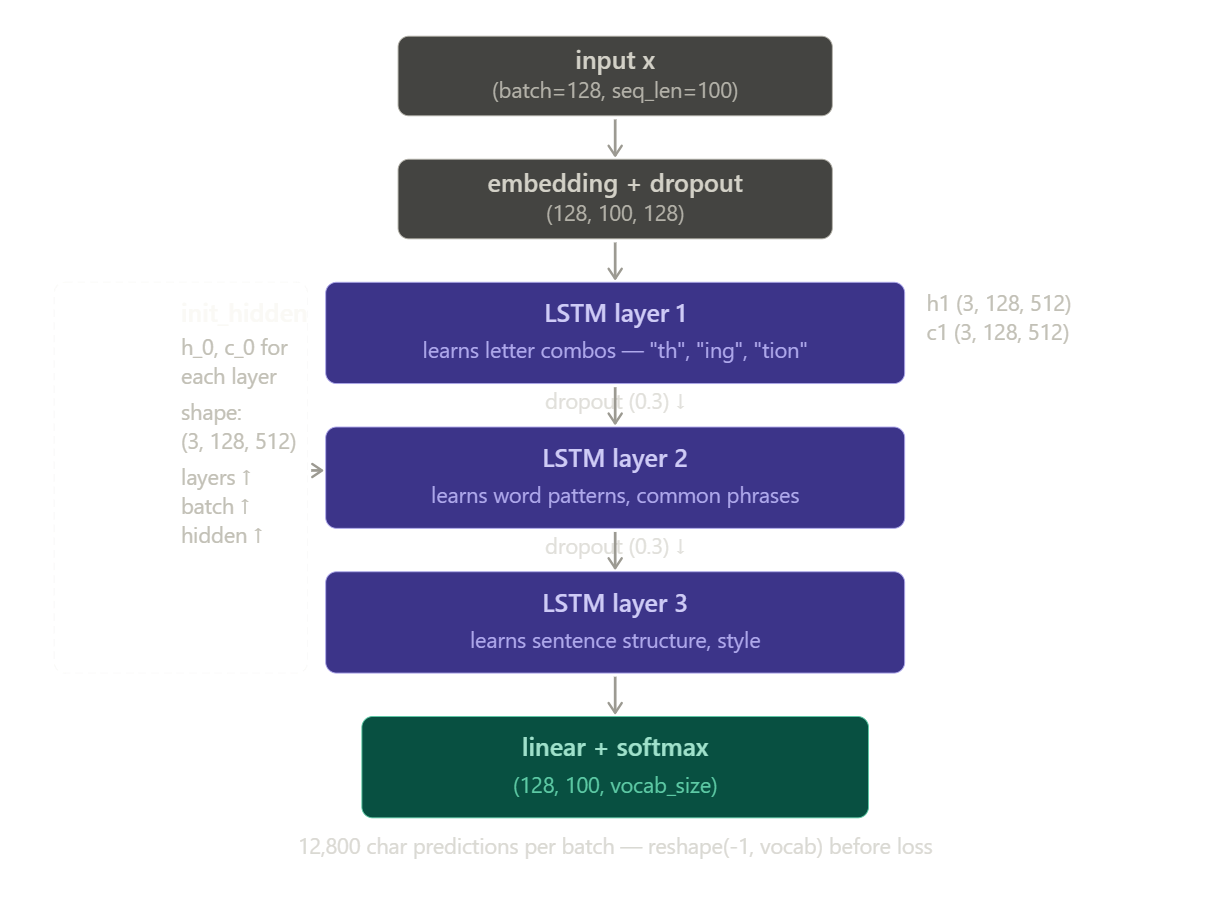

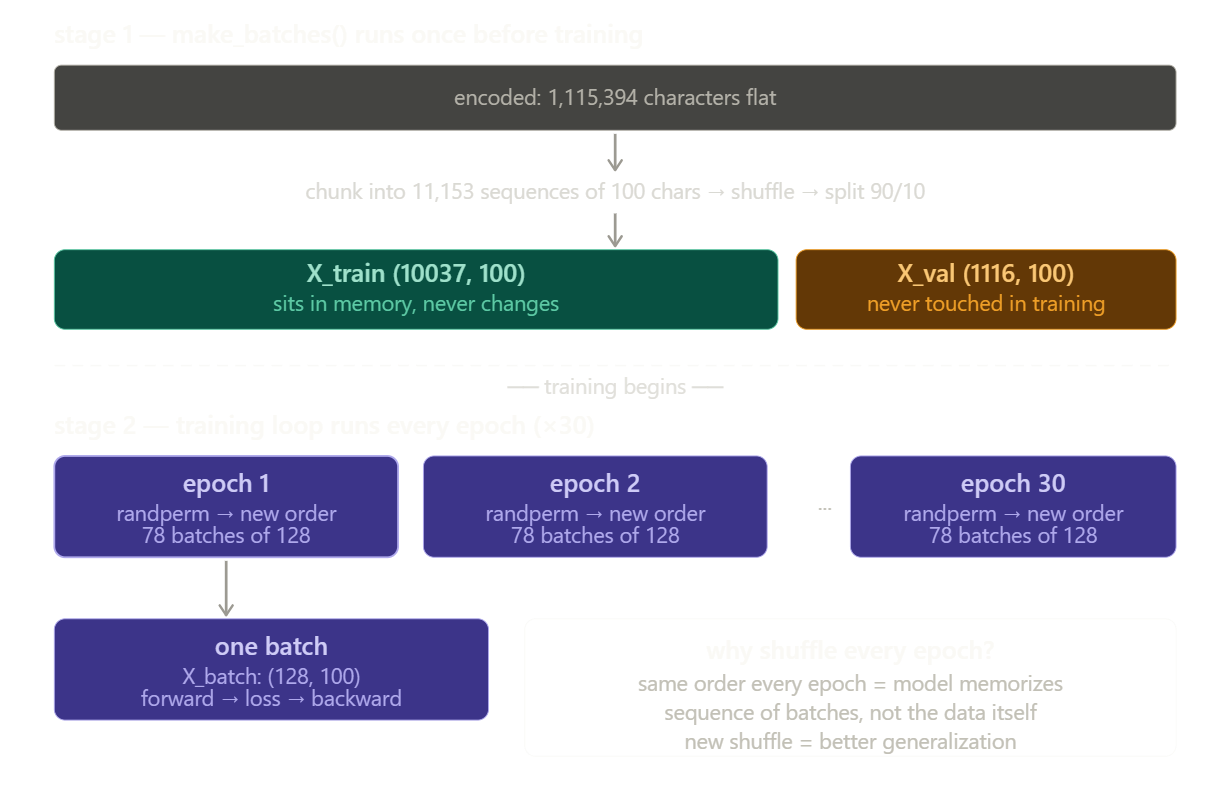

In [4]:
EPOCHS    = 30
LR        = 0.002
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# LR scheduler 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

train_losses = []
val_losses   = []
best_val_loss = float('inf')

print(f"\nTraining on {device}...")
print("─" * 55)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss  = 0
    n_batches   = 0
    start_time  = time.time()

    # Mini-batch training
    perm = torch.randperm(X_train.shape[0])
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        idx     = perm[i:i + BATCH_SIZE]
        X_batch = X_train[idx].to(device)
        y_batch = y_train[idx].to(device)

        optimizer.zero_grad()
        logits, _ = model(X_batch)

        loss = criterion(
            logits.reshape(-1, VOCAB),
            y_batch.reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits, _ = model(X_val.to(device))
        val_loss = criterion(
            val_logits.reshape(-1, VOCAB),
            y_val.to(device).reshape(-1)
        )

    avg_train = epoch_loss / n_batches
    avg_val   = val_loss.item()
    train_ppl = np.exp(avg_train)
    val_ppl   = np.exp(avg_val)
    elapsed   = time.time() - start_time

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    # Saving best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'day21_best_model.pth')
        saved = "saved"
    else:
        saved = ""

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {avg_train:.3f} (PPL: {train_ppl:.1f}) | "
          f"Val Loss: {avg_val:.3f} (PPL: {val_ppl:.1f}) | "
          f"{elapsed:.1f}s {saved}")

print(f"\nBest val loss: {best_val_loss:.3f} "
      f"(PPL: {np.exp(best_val_loss):.1f})")


Training on cuda...
───────────────────────────────────────────────────────
Epoch 01/30 | Train Loss: 2.714 (PPL: 15.1) | Val Loss: 2.125 (PPL: 8.4) | 3.7s saved
Epoch 02/30 | Train Loss: 1.963 (PPL: 7.1) | Val Loss: 1.719 (PPL: 5.6) | 2.9s saved
Epoch 03/30 | Train Loss: 1.698 (PPL: 5.5) | Val Loss: 1.540 (PPL: 4.7) | 2.9s saved
Epoch 04/30 | Train Loss: 1.569 (PPL: 4.8) | Val Loss: 1.455 (PPL: 4.3) | 3.0s saved
Epoch 05/30 | Train Loss: 1.495 (PPL: 4.5) | Val Loss: 1.410 (PPL: 4.1) | 3.0s saved
Epoch 06/30 | Train Loss: 1.445 (PPL: 4.2) | Val Loss: 1.371 (PPL: 3.9) | 3.0s saved
Epoch 07/30 | Train Loss: 1.408 (PPL: 4.1) | Val Loss: 1.351 (PPL: 3.9) | 3.0s saved
Epoch 08/30 | Train Loss: 1.380 (PPL: 4.0) | Val Loss: 1.332 (PPL: 3.8) | 3.0s saved
Epoch 09/30 | Train Loss: 1.357 (PPL: 3.9) | Val Loss: 1.319 (PPL: 3.7) | 3.0s saved
Epoch 10/30 | Train Loss: 1.338 (PPL: 3.8) | Val Loss: 1.306 (PPL: 3.7) | 3.1s saved
Epoch 11/30 | Train Loss: 1.321 (PPL: 3.7) | Val Loss: 1.300 (PPL: 3.7) 

In [5]:
model.load_state_dict(torch.load('day21_best_model.pth', map_location=device))
model.eval()

def generate(model, seed_text, length=300, temperature=1.0):
    """
    Generate text character by character.
    temperature < 1 → conservative, repetitive
    temperature = 1 → balanced
    temperature > 1 → creative, chaotic
    """
    model.eval()

    # Prime the model with seed text (warm up hidden state)
    chars_in = [char2idx.get(c, 0) for c in seed_text]
    x        = torch.tensor(chars_in, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        _, h = model(x)  # run seed through, capture hidden state

        generated = seed_text
        # Start generating from last char of seed
        x = torch.tensor([[chars_in[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            logits, h = model(x, h)
            logits    = logits[0, -1, :] / temperature
            probs     = F.softmax(logits, dim=0)
            next_char = torch.multinomial(probs, 1).item()

            generated += idx2char[next_char]
            x = torch.tensor([[next_char]], dtype=torch.long).to(device)

    return generated


# Generate with different temperatures
seed = "ROMEO:\nWhat light through yonder window breaks"

print("\n" + "═"*55)
print("GENERATED TEXT SAMPLES")
print("═"*55)

for temp in [0.5, 0.8, 1.0, 1.2]:
    print(f"\n── Temperature: {temp} ──────────────────────────────")
    print(generate(model, seed, length=250, temperature=temp))
    print()


═══════════════════════════════════════════════════════
GENERATED TEXT SAMPLES
═══════════════════════════════════════════════════════

── Temperature: 0.5 ──────────────────────────────
ROMEO:
What light through yonder window breaks you that?

LUCENTIO:
The market-place, I will be so.

MENENIUS:
The son is come.

LUCIO:
How now, dear Clarence! who's the prince?

ARIEL:
Every word is of the book of the spirits, and make you a
breast courteous as a consent to be a word.

GREMIO:



── Temperature: 0.8 ──────────────────────────────
ROMEO:
What light through yonder window breaks our words!

NORTHUMBERLAND:
When he hath not too fair in provide which
Romeo are will.

LEONTES:
I am required from me
To any exchange-encies with brief.
More, sir, still in the earth in barrina.
The crown glides adversaries, that he means,
Which so


── Temperature: 1.0 ──────────────────────────────
ROMEO:
What light through yonder window breaks it, warm?

OXFORD:
I'll pass to wear us.

BAPTISTA:
Sir Hach, Pau

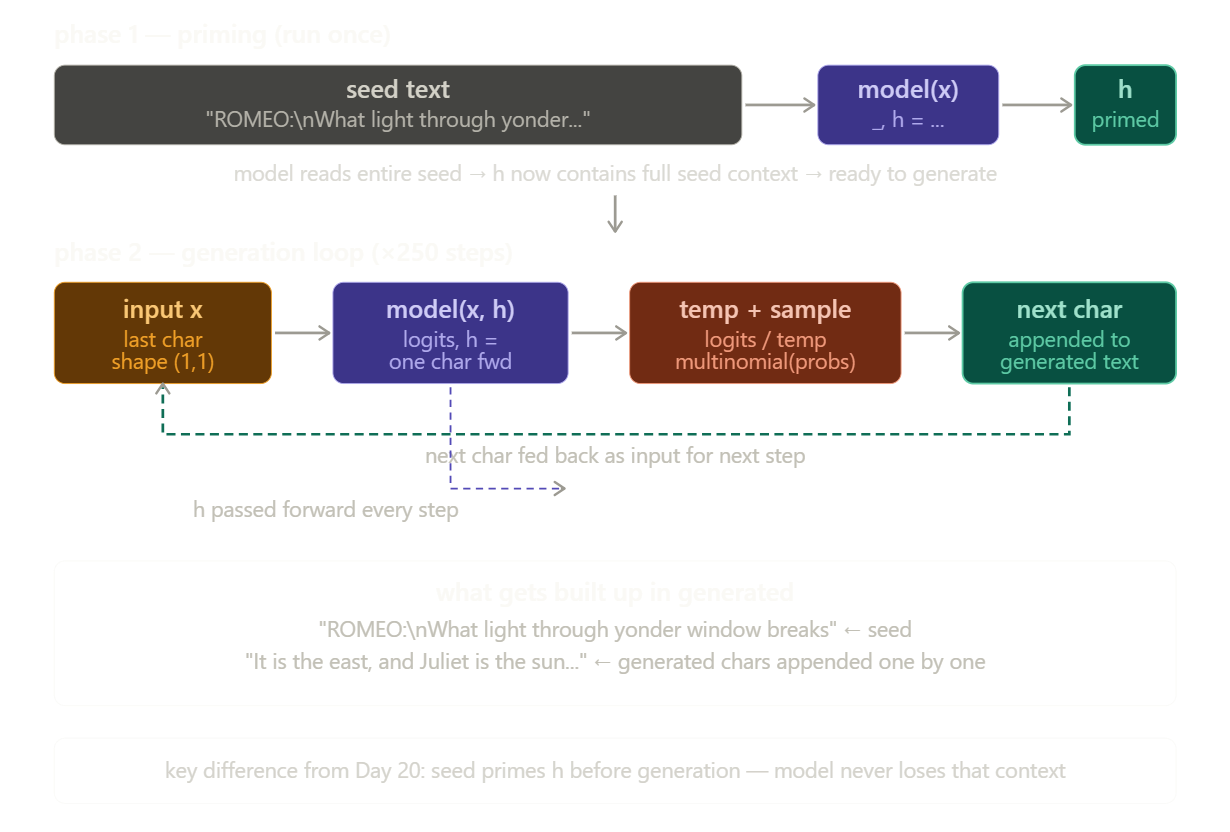

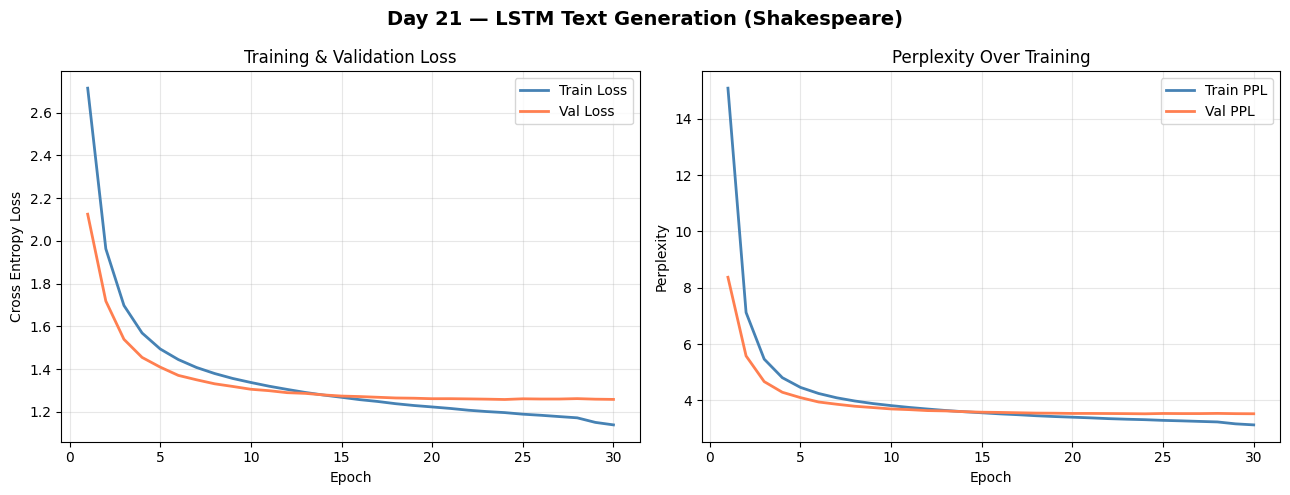

Plot saved as day21_text_generation.png

── Final Summary ───────────────────────────────────
  Model parameters: 5,558,977
  Best Val Loss:    1.258
  Best Val PPL:     3.5
  Checkpoint saved: day21_best_model.pth


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Day 21 — LSTM Text Generation (Shakespeare)',
             fontsize=14, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# Loss curves
axes[0].plot(epochs_range, train_losses, label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, val_losses,   label='Val Loss',   color='coral',     linewidth=2)
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity curves
train_ppls = [np.exp(l) for l in train_losses]
val_ppls   = [np.exp(l) for l in val_losses]
axes[1].plot(epochs_range, train_ppls, label='Train PPL', color='steelblue', linewidth=2)
axes[1].plot(epochs_range, val_ppls,   label='Val PPL',   color='coral',     linewidth=2)
axes[1].set_title('Perplexity Over Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final summary
print(f"\n── Final Summary ───────────────────────────────────")
print(f"  Model parameters: {total_params:,}")
print(f"  Best Val Loss:    {best_val_loss:.3f}")
print(f"  Best Val PPL:     {np.exp(best_val_loss):.1f}")
print(f"  Checkpoint saved: day21_best_model.pth")